In [1]:
import numpy as np
from lstm import LoanDefaultModel
import torch

import sys
import os
sys.path.append(os.path.abspath(".."))
from Explainable_AI.xai import compute_ig_importance_global, compute_ig_importance_local

/opt/anaconda3/envs/creditrisk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = np.load("../data/credit_risk_dataset_5k_padded.npz", allow_pickle=True)

X_padded      = data["X_padded"]
y_padded      = data["y_padded"]
customer_ids  = data["customer_ids"]
feature_cols  = data["feature_cols"]
countries     = data['country']

In [3]:
device = 'cpu'
model = LoanDefaultModel(input_size=33, hidden_size=32)
model.load_state_dict(torch.load('../model/best_model.pth'))
model.eval()
model = model.to(device)

## Testing of methods

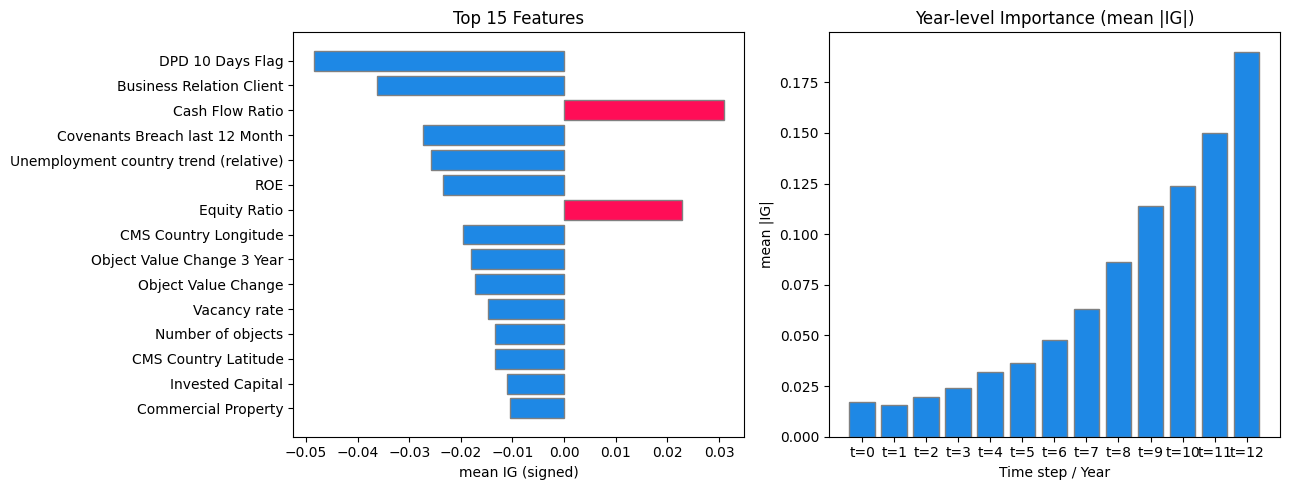

In [5]:
all_attr, global_feat_imp_signed, global_year_imp_abs, fig = compute_ig_importance_global(model=model, X_test=X_padded, feature_cols=feature_cols)

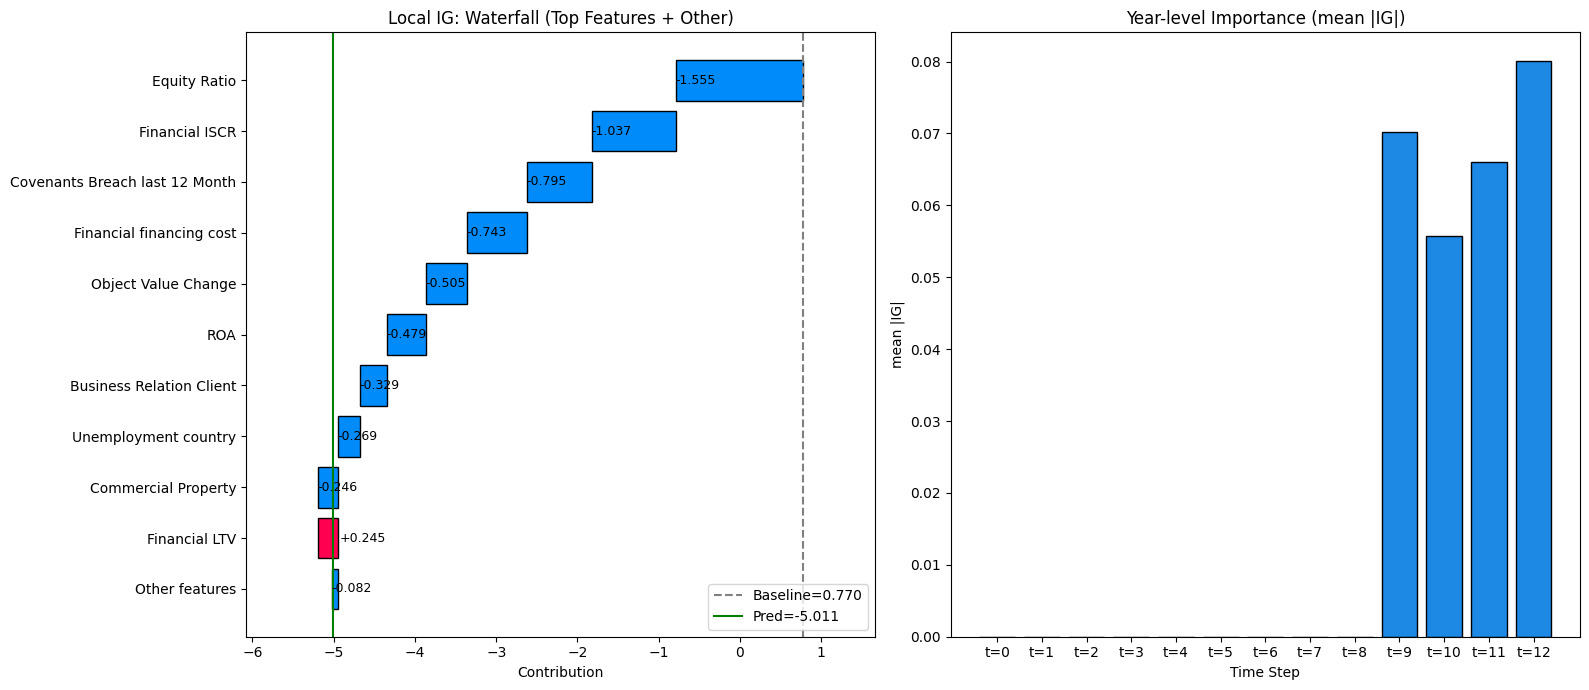

In [6]:
attr, feature_importance, fig = compute_ig_importance_local(model, X_padded[0], feature_cols)

## Ethical AI

In [4]:
from Ethical_AI.fairness import evaluate_fairness, evaluate_fairness_pair
preds = []
for i in range(X_padded.shape[0]):
    output = model(torch.tensor(X_padded[i], dtype=torch.float32).unsqueeze(0))
    pred = 1 if output > 0.5 else 0
    preds.append(pred)

### Comparison across all countries


=== Overall Metrics ===
accuracy          0.950116
selection_rate    0.150424
TPR               0.918630
FPR               0.045587
dtype: float64

=== Group Metrics ===
                     accuracy  selection_rate       TPR       FPR
sensitive_feature_0                                              
AT                   0.952756        0.106299  1.000000  0.050209
BE                   0.941176        0.107843  0.666667  0.011494
CH                   0.947115        0.149038  0.916667  0.048913
CZ                   0.959641        0.152466  0.878788  0.026316
DE                   0.947170        0.135849  0.958333  0.053942
DK                   0.966851        0.198895  0.968750  0.033557
ES                   0.936090        0.180451  1.000000  0.072340
FI                   0.960227        0.119318  0.937500  0.037500
FR                   0.943478        0.147826  0.862069  0.044776
GB                   0.970954        0.112033  0.916667  0.023041
HU                   0.954887        

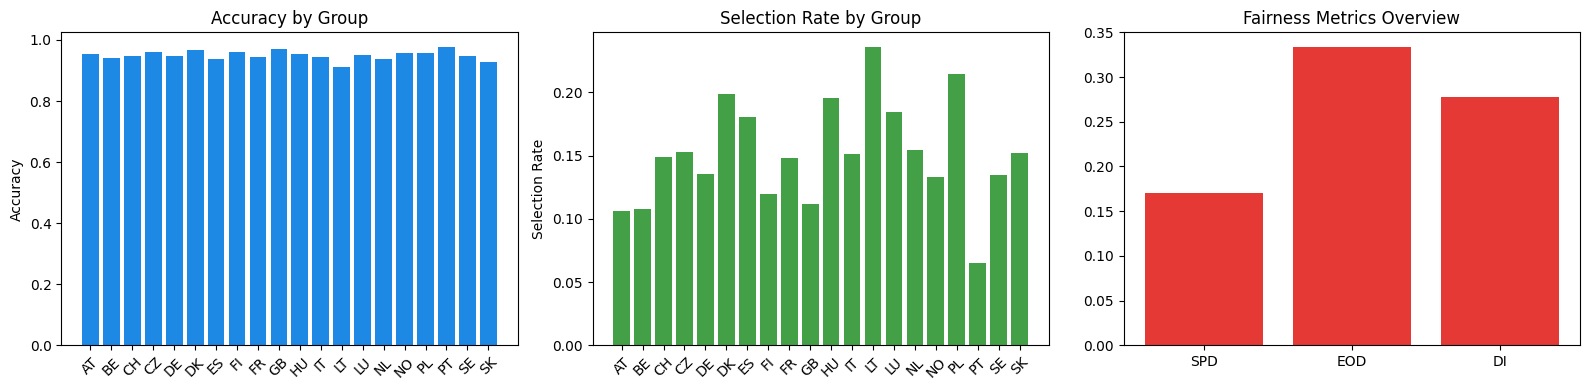

(<fairlearn.metrics._metric_frame.MetricFrame at 0x15ad43760>,
 {'SPD': 0.17019259933272674,
  'EOD': 0.33333333333333337,
  'DI': 0.27783140283140284})

In [5]:
evaluate_fairness(y_true=y_padded, y_pred=preds, sensitive_attr=countries)

### Pairwise Comparison


=== Pairwise Fairness: PT vs LU ===
Samples kept: 271 / 3889

=== Overall Metrics ===
accuracy          0.966790
selection_rate    0.110701
TPR               0.838710
FPR               0.016667
dtype: float64

=== Group Metrics ===
                     accuracy  selection_rate       TPR       FPR
sensitive_feature_0                                              
LU                   0.951456        0.184466  0.818182  0.012346
PT                   0.976190        0.065476  0.888889  0.018868


=== FAIRNESS REPORT ===
SPD = 0.119 → Unfair (>|0.1|). Large group disparity.
DI = 0.355 → Unfair. Outside acceptable interval [0.8, 1.25].
EOD = 0.071 → Fair


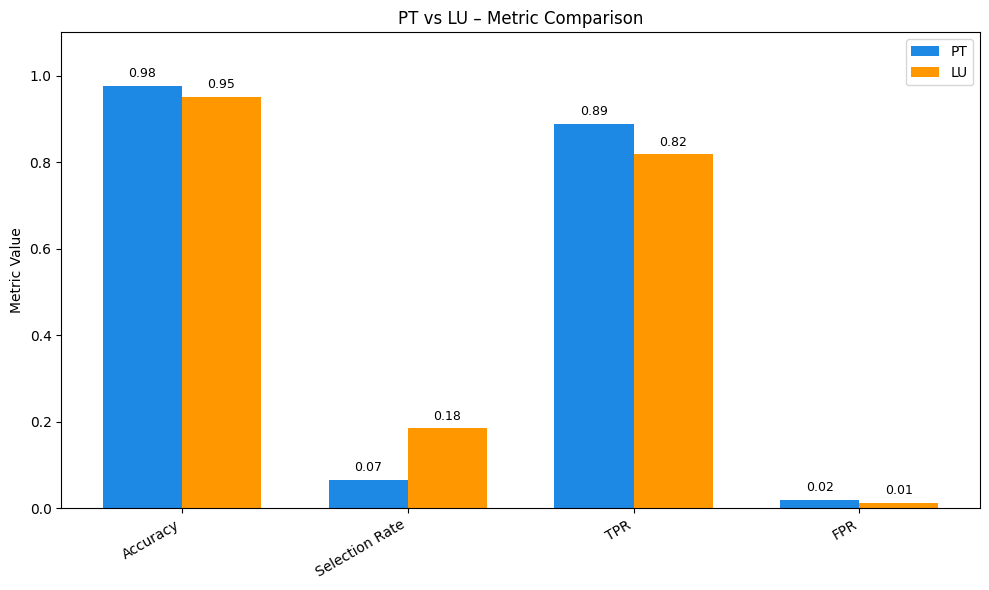


Sample counts: PT = 168, LU = 103


(<fairlearn.metrics._metric_frame.MetricFrame at 0x15ad8a470>,
 {'SPD': 0.11898982894128525,
  'EOD': 0.07070707070707061,
  'DI': 0.3549498746867168})

In [6]:
evaluate_fairness_pair(y_true=y_padded, y_pred=preds, sensitive_attr=countries, group_a="PT", group_b='LU')